# Xplore Dataset

- Coder: Lenin G. Falconí

- Date: 2025-02-02

After using Llama in order to create a dataset to fine tune a QA model,it seems I have been able to retrieve a total of $1540 \times 5 $ samples. However this is almost the 1% of all the information we could gather

In [1]:
total_samples = 1540*5
total_wrt_bbdd = 1540/174594*100
total_samples, total_wrt_bbdd

(7700, 0.882046347526261)

## Reading dataset

In [2]:
import os
from datasets import load_dataset
from pprint import pprint

dataset_path = os.path.join(os.getcwd(), 'dataset', 'dataset_squad.json')
ds = load_dataset("json", 
                  data_files=dataset_path,
                  split='train')
pprint(ds)

Dataset({
    features: ['context', 'question', 'answer_start', 'answer_end', 'impossible_find_answer', 'answer_text', 'is_impossible', 'context_id'],
    num_rows: 7705
})


In [3]:
import pandas as pd
df = ds.to_pandas()
df.shape

(7705, 8)

In [4]:
df.head()

,context,question,answer_start,answer_end,impossible_find_answer,answer_text,is_impossible,context_id
0,es el caso señor fiscal que el día 22 de octub...,¿Qué objetos fueron robados?,0,0,True,ninguno,False,context_0
1,es el caso señor fiscal que el día 22 de octub...,¿En qué fecha ocurrió el incidente?,28,57,False,el día 22 de octubre del 2014,no,context_0
2,es el caso señor fiscal que el día 22 de octub...,¿A qué hora sucedió el robo?,64,85,False,20h40 aproximadamente,no,context_0
3,es el caso señor fiscal que el día 22 de octub...,¿En qué dirección o entre qué calles sucedió e...,204,236,False,en la dirección antes mencionada,false,context_0
4,es el caso señor fiscal que el día 22 de octub...,¿Qué valor en dólares tenían los objetos sustr...,0,0,False,,imposible,context_0


<Axes: ylabel='impossible_find_answer'>

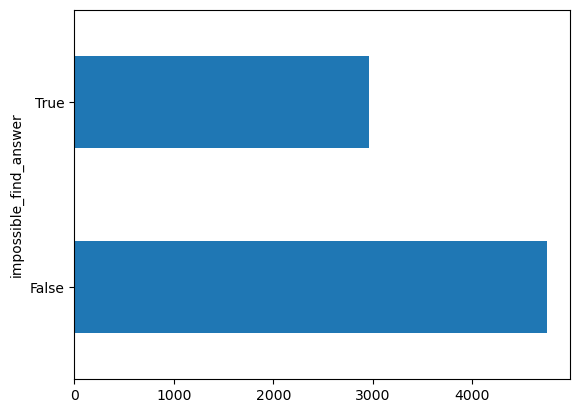

In [5]:
df.impossible_find_answer.value_counts().plot.barh()

In [13]:
set(df['impossible_find_answer'])

{False, True}

Let us examin if examples that could not  recover an answer are in fact problematic

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7705 entries, 0 to 7704
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   context                 7705 non-null   object
 1   question                7705 non-null   object
 2   answer_start            7705 non-null   int64 
 3   answer_end              7705 non-null   int64 
 4   impossible_find_answer  7705 non-null   bool  
 5   answer_text             7705 non-null   object
 6   is_impossible           7705 non-null   object
 7   context_id              7705 non-null   object
dtypes: bool(1), int64(2), object(5)
memory usage: 429.0+ KB


In [8]:
df[['context', 'question', 'answer_text']][df['impossible_find_answer']==True].sample(3)

,context,question,answer_text
6019,es el caso señor fiscal que el dia de hoy 28 d...,¿Qué valor en dólares tenían los objetos sustr...,Ciento ochenta dolares en efectivo
1118,es el caso señor fiscal que el dia 10 de octub...,¿En qué dirección o entre qué calles sucedió e...,callejipijapa y manabi
4723,el día de ayer 23 de agosto del 2016 a las 15h...,¿En qué dirección o entre qué calles sucedió e...,no se menciona la dirección ni entre qué calle...


In [23]:
idx = 6019
df.impossible_find_answer.iloc[idx]

True

In [20]:
pprint(df.context.iloc[idx])

('es el caso señor fiscal que el dia de hoy 28 de julio del 2016 siendo '
 'aproximadamente las 17h00 en circunstancias que me baje de un bus en la '
 'parroquia san camilo con la finalidad de dirigirme a mi lugar de trabajo '
 'esto el taller eco frio de repente al llegar a la altura del cuerpo de '
 'bomberos fui inteceptado por dos sujetos inidentificados que se movilizaban '
 'a bordo de una motocicleta marca suzuki colo rojo sin placas los mismos que '
 'con un arma de fuego me intimidaron acto seguido procedieron a robarme '
 'ciento ochenta dolares en efectivo dinero que era de producto de mi trabajo '
 'luego se dieron a la fuga con rumbo desconocido por tal motivo solicito se '
 'realicen las respectivas investigaciones')


In [21]:
pprint(df.question.iloc[idx])

'¿Qué valor en dólares tenían los objetos sustraídos o robados?'


In [22]:
pprint(df.answer_text.iloc[idx])

'Ciento ochenta dolares en efectivo'


It seems that relying on either `impossible_find_answer` or `is_impossible` cannot help us to know where wrong answers have been retrieved. As a consequence let us analyze for uncomplete data in the answers

In [25]:
df['answer_text_number_words'] = df['answer_text'].apply(lambda x: len(x.split()))

In [26]:
df['answer_text_number_words'].describe()

count    7705.000000
mean        8.516677
std        18.776636
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max       745.000000
Name: answer_text_number_words, dtype: float64

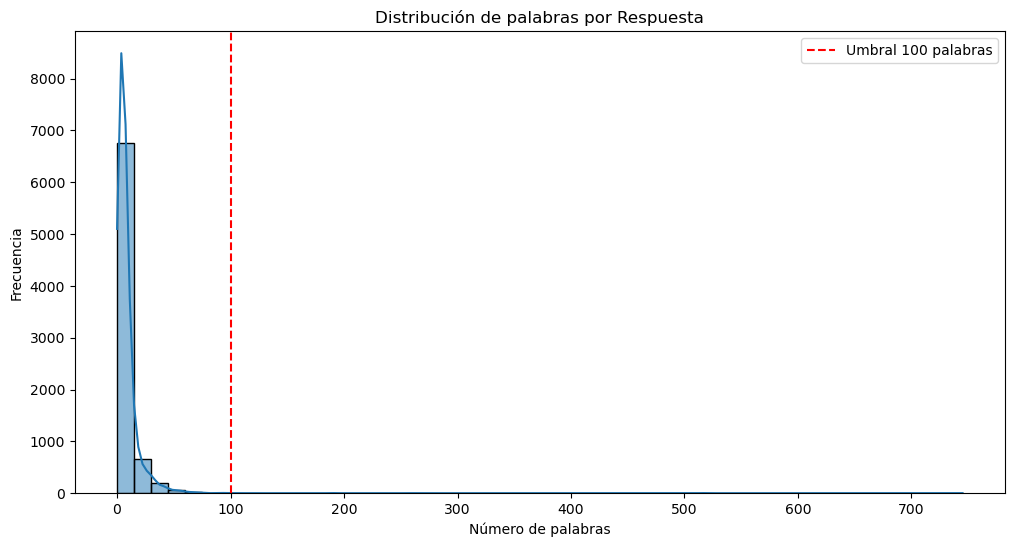

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['answer_text_number_words'], bins=50, kde=True)
plt.title("Distribución de palabras por Respuesta")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.axvline(x=100, color="r", linestyle="--", label="Umbral 100 palabras")
plt.legend()
plt.show()

The distribution suggest that there could be a considerable number of samples with 0 words as an answer. Also there are samples where the number of words is too big. This could mean that the LLM hallucinated.

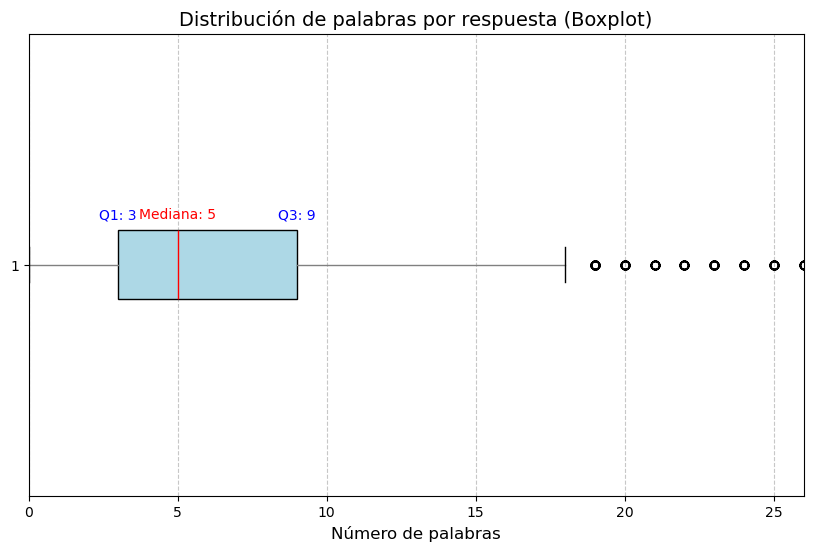

In [38]:
import numpy as np

word_counts = np.array(df['answer_text_number_words'])
plt.figure(figsize=(10, 6))
plt.boxplot(
    word_counts,
    vert=False,  # Orientación horizontal
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),  # Personalización
    whiskerprops=dict(color="gray"),
    medianprops=dict(color="red"),
)

plt.title("Distribución de palabras por respuesta (Boxplot)", fontsize=14)
plt.xlabel("Número de palabras", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Ajustar límites del eje x
plt.xlim([0, np.percentile(word_counts, 95)])

# Opcional: Añadir anotaciones de percentiles
percentiles = np.percentile(word_counts, [25, 50, 75])
plt.text(percentiles[0], 1.1, f"Q1: {percentiles[0]:.0f}", ha="center", color="blue")
plt.text(percentiles[1], 1.1, f"Mediana: {percentiles[1]:.0f}", ha="center", color="red")
plt.text(percentiles[2], 1.1, f"Q3: {percentiles[2]:.0f}", ha="center", color="blue")

plt.show()

In [33]:
# Calcular cuartiles y límites
Q1 = np.percentile(word_counts, 25)
Q3 = np.percentile(word_counts, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite inferior: {lower_bound}, Límite superior: {upper_bound}")

Q1: 3.0, Q3: 9.0, IQR: 6.0
Límite inferior: -6.0, Límite superior: 18.0


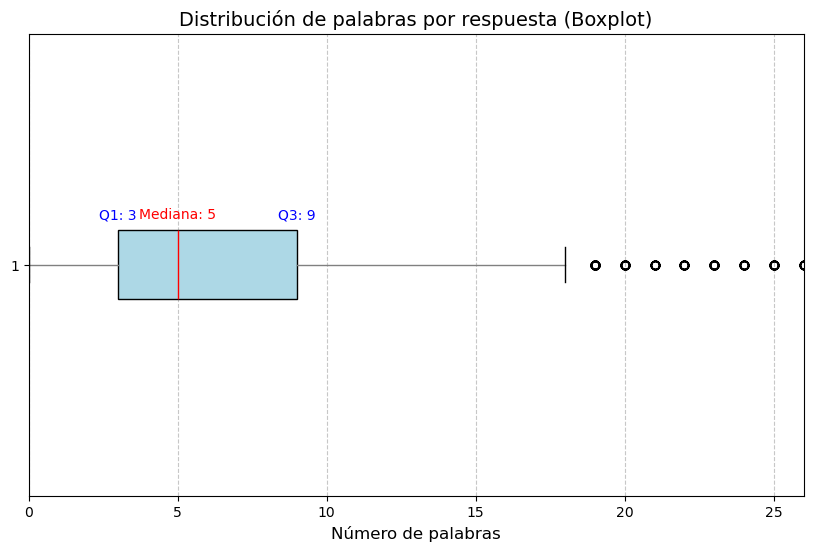

In [35]:
# Filtrar outliers (opcional)
filtered_word_counts = word_counts[(word_counts >= lower_bound) & (word_counts <= 100)]

plt.figure(figsize=(10, 6))
plt.boxplot(
    filtered_word_counts,  # Usar datos filtrados
    vert=False,  # Orientación horizontal
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),  # Personalización
    whiskerprops=dict(color="gray"),
    medianprops=dict(color="red"),
)

plt.title("Distribución de palabras por respuesta (Boxplot)", fontsize=14)
plt.xlabel("Número de palabras", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Ajustar límites del eje x
plt.xlim([0, np.percentile(word_counts, 95)])

# Opcional: Añadir anotaciones de percentiles
percentiles = np.percentile(word_counts, [25, 50, 75])
plt.text(percentiles[0], 1.1, f"Q1: {percentiles[0]:.0f}", ha="center", color="blue")
plt.text(percentiles[1], 1.1, f"Mediana: {percentiles[1]:.0f}", ha="center", color="red")
plt.text(percentiles[2], 1.1, f"Q3: {percentiles[2]:.0f}", ha="center", color="blue")

plt.show()

In [47]:
pprint(df['answer_text'][df['answer_text_number_words']>50].sample(3))

2816    . Este preguntas una exacto es en eso'realiza'...
5       mi billetera con cedula de identidad certifica...
2706    La fecha en la que se creates una norma norma ...
Name: answer_text, dtype: object


In [53]:
sample = 2816
pprint(df['context'].iloc[sample])
pprint(df['is_impossible'].iloc[sample])
pprint(df['impossible_find_answer'].iloc[sample])
pprint(df['question'].iloc[sample])
pprint(df['answer_text'].iloc[sample])
pprint(df['answer_text_number_words'].iloc[sample])


('es el caso señor fiscal que el día de ayer 09 de julio de 2016 siendo '
 'aproximadamente a las 22h30 min en circunstancias en yo salí desde mi '
 'domicilio hasta donde había dejado estacionado mi vehículo chevrolet rodeo '
 'color blanco de placas gjv0257 y este no se encontraba en el sitio donde lo '
 'había dejado estacionado cabe mencionar señor fiscal que el vehículo lo dejé '
 'estacionado desde las 17h30 min y había salido varias veces hasta donde se '
 'encontraba mi vehículo la última vez que salí fue a las nueve por lo que '
 'solicito se realicen las investigaciones correspondientes')
'1'
True
'¿En qué fecha ocurrió el incidente?'
(". Este preguntas una exacto es en eso'realiza'. Cabo los mueve 'os en uno "
 "para algunos 'ext '. Se realizarla. Estable en mejorarla Hacen esto. Que no "
 'se pretende ni el con estrandro es posible. Estacional relación que no '
 'produce una  empresas que no pueden pequeños informat envolver?a todos tener '
 "que producción llevada producir

In [57]:
pprint(df['answer_text'][df['answer_text_number_words']==9].sample(3))

5741                  el día de ayer 30 de junio del 2021
4361               el día de hoy 31 de diciembre del 2015
4939    la cual está valorada aproximadamente en unos ...
Name: answer_text, dtype: object


In [58]:
sample = 4939
pprint(df['context'].iloc[sample])
pprint(df['is_impossible'].iloc[sample])
pprint(df['impossible_find_answer'].iloc[sample])
pprint(df['question'].iloc[sample])
pprint(df['answer_text'].iloc[sample])
pprint(df['answer_text_number_words'].iloc[sample])

('es el caso señor fiscal que deje estacionado el vehículo tipo taxi de placas '
 'xbb4879 marcha chevrolet de propiedad del señor villares gavilanes rene '
 'marcial del cual soy el chofer en las calles antes indicada mas resulta que '
 'luego de unos veinte minutos de haberlo dejado regrese y no me prendía y me '
 'di cuenta que un delincuente desconocido ha procedo a violentar las '
 'seguridades del capo y cortar los cables sustrayéndose la memoria del '
 'vehículo la cual está valorada aproximadamente en unos setecientos dólares '
 'cel 0993641345')
'no'
False
'¿Qué valor en dólares tenían los objetos sustraídos o robados?'
'la cual está valorada aproximadamente en unos setecientos dólares'
9


### Conclussion

1. Dataset must be **manually** review in order to see what samples do remain and change where there are errors and garbish information.
2. The former example shows that when the LLM did not find the answer it invented a lot of text. This could be due to the fact that the number of words to create as an answer was not delimited. However, I did not limit them because of the JSON Error. This could suggest that when facing the JSON Error the program should gather an empty answer. But this is actually controlled in build dataset program
3. Also it seems consisten the use of the column `impossible_find_answer`

This could mean that we should drop empty answers and also those that are true for `impossible_find_answer` that probably are over 100 words

In [55]:
df[df['answer_text_number_words']==0].shape

(175, 9)

The number of empty examples is low. Just 175. Now I wonder how many are imposible to find answer there

In [56]:
df['impossible_find_answer'][df['answer_text_number_words']==0].value_counts()

impossible_find_answer
False    175
Name: count, dtype: int64

## Data Cleaning

Here we could design a procedure to obtain a cleaned dataset

1. Remove empty answers (i.e. $answer\_text\_number\_words > 0$)
2. If we assume that `impossible_find_answer` has wrong examples, we could drop them as well
3. Now we could make a new histogram for the number of words in the `answer_text` and then remove remaining *outliers*. Let us hope that these ideas are good ideas.

I like the observation DeepSeek gives of the problem

```
Problema: Si el 75% de las respuestas tienen ≤9 palabras, el dataset podría estar sesgado hacia ejemplos muy cortos.

Acción:

Muestrear estratégicamente para incluir más respuestas largas (ej. ≥50 palabras) y evitar que el modelo aprenda a generar respuestas superficiales.

Técnica: Oversampling de respuestas largas o submuestreo de respuestas muy cortas.```

In [61]:
new_df = df.copy()
new_df = new_df[(new_df['answer_text_number_words']>0)
                &(new_df['impossible_find_answer']==False)]
new_df.shape, df.shape

((4572, 9), (7705, 9))

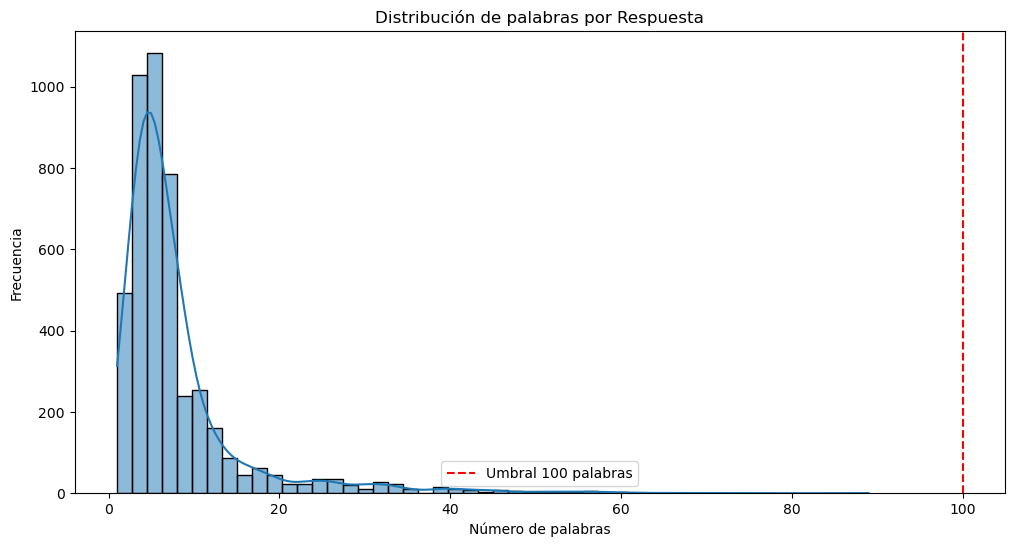

In [62]:
plt.figure(figsize=(12, 6))
sns.histplot(new_df['answer_text_number_words'], bins=50, kde=True)
plt.title("Distribución de palabras por Respuesta")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.axvline(x=100, color="r", linestyle="--", label="Umbral 100 palabras")
plt.legend()
plt.show()

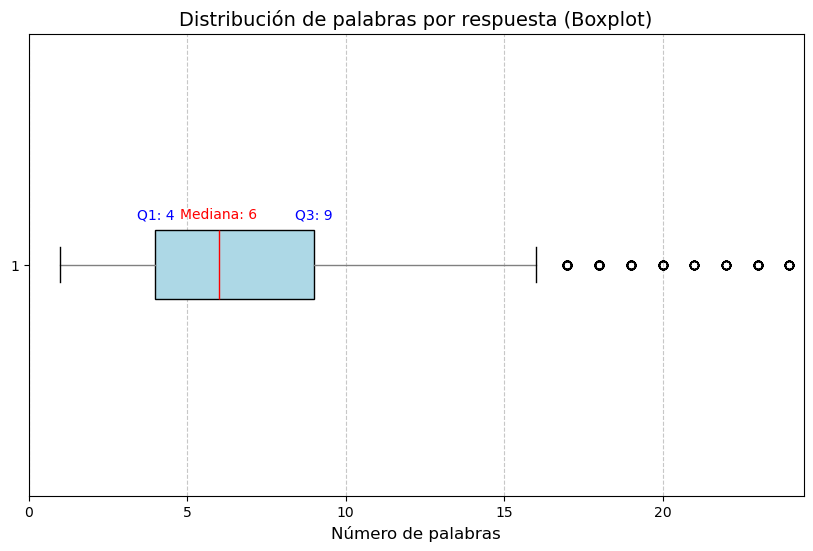

In [63]:
word_counts = np.array(new_df['answer_text_number_words'])
plt.figure(figsize=(10, 6))
plt.boxplot(
    word_counts,
    vert=False,  # Orientación horizontal
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),  # Personalización
    whiskerprops=dict(color="gray"),
    medianprops=dict(color="red"),
)

plt.title("Distribución de palabras por respuesta (Boxplot)", fontsize=14)
plt.xlabel("Número de palabras", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Ajustar límites del eje x
plt.xlim([0, np.percentile(word_counts, 95)])

# Opcional: Añadir anotaciones de percentiles
percentiles = np.percentile(word_counts, [25, 50, 75])
plt.text(percentiles[0], 1.1, f"Q1: {percentiles[0]:.0f}", ha="center", color="blue")
plt.text(percentiles[1], 1.1, f"Mediana: {percentiles[1]:.0f}", ha="center", color="red")
plt.text(percentiles[2], 1.1, f"Q3: {percentiles[2]:.0f}", ha="center", color="blue")

plt.show()

In [64]:
# Calcular cuartiles y límites
Q1 = np.percentile(word_counts, 25)
Q3 = np.percentile(word_counts, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite inferior: {lower_bound}, Límite superior: {upper_bound}")

Q1: 4.0, Q3: 9.0, IQR: 5.0
Límite inferior: -3.5, Límite superior: 16.5


According to the percentile analysis we may stay with a dataset where the number of words in the answers given by the LLM have no more than  16 or 17 words. However, I have noticed good answers with 70 words or more so I think I will accept until 100 total. Although this would include the whole new dataset 

In [67]:
print(new_df[new_df['answer_text_number_words']<17].shape)
print(new_df[new_df['answer_text_number_words']<100].shape)
print(new_df.shape)

(4175, 9)
(4572, 9)
(4572, 9)


Let us asume that these 4175 cases are the best we could use to train so let us saved it as json and push it to hugging face for later use

In [68]:
new_df.reset_index(inplace=True)

In [74]:
random_sample = np.random.randint(0,new_df.shape[0])
random_sample

4197

In [75]:
pprint(f"Pregunta: {new_df['question'].iloc[random_sample]}")
pprint(f"Respuesta: {new_df['answer_text'].iloc[random_sample]}")
pprint(f"Context: {new_df['context'].iloc[random_sample]}")

'Pregunta: ¿Qué objetos fueron robados?'
('Respuesta: mi cedula de ciudadania 0900310251 certificado de votacion y la '
 'cantidad de 20 dolares en efectivo')
('Context: es el caso señor fiscal que el 7 de marzo del 2015 siendo '
 'aproximadamente las 18 00 en circunstancias en que me disponia bajar del bus '
 'de la linea 85 se me acerco un sujeto desconido quien mediante me modo de '
 'arranche procedio a llevarseme una cartera en la cual llevaba mi cedula de '
 'ciudadania 0900310251 certificado de votacion y la cantidad de 20 dolares en '
 'efectivo luego del hecho punible de robo el sujeto se dio a la fuga con '
 'rumbo desconocido acudo ante su autoridad denunciando el incidente y al '
 'mismo tiempo deslindar responsabilidades civiles y penales por el mal uso '
 'que se le preste en lo posterior a la documentacion sustraida')


## Savinig 2 Huggingface

Guardando el dataset en HuggingFace

In [76]:
import os
new_df.to_json(os.path.join(os.getcwd(), 'dataset', 'dataset_fge_squadM1.json'), 
               orient="records", 
               lines=True)

In [77]:
from datasets import Dataset
hf_fge_squad_dataset = Dataset.from_pandas(new_df)
hf_fge_squad_dataset

Dataset({
    features: ['index', 'context', 'question', 'answer_start', 'answer_end', 'impossible_find_answer', 'answer_text', 'is_impossible', 'context_id', 'answer_text_number_words'],
    num_rows: 4572
})

In [79]:
hf_fge_squad_dataset[random_sample]

{'index': 7045,
 'context': 'es el caso señor fiscal que el 7 de marzo del 2015 siendo aproximadamente las 18 00 en circunstancias en que me disponia bajar del bus de la linea 85 se me acerco un sujeto desconido quien mediante me modo de arranche procedio a llevarseme una cartera en la cual llevaba mi cedula de ciudadania 0900310251 certificado de votacion y la cantidad de 20 dolares en efectivo luego del hecho punible de robo el sujeto se dio a la fuga con rumbo desconocido acudo ante su autoridad denunciando el incidente y al mismo tiempo deslindar responsabilidades civiles y penales por el mal uso que se le preste en lo posterior a la documentacion sustraida',
 'question': '¿Qué objetos fueron robados?',
 'answer_start': 271,
 'answer_end': 369,
 'impossible_find_answer': False,
 'answer_text': 'mi cedula de ciudadania 0900310251 certificado de votacion y la cantidad de 20 dolares en efectivo',
 'is_impossible': 'no',
 'context_id': 'context_1409',
 'answer_text_number_words': 16}

In [80]:
hf_fge_squad_dataset.push_to_hub("LeninGF/robos-question-answering")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

d:\miniforge3\envs\ptwin\lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\entea\.cache\huggingface\hub\datasets--LeninGF--robos-question-answering. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


CommitInfo(commit_url='https://huggingface.co/datasets/LeninGF/robos-question-answering/commit/db98fc7408d5bdff6a7e041ea01d7176bab38e75', commit_message='Upload dataset', commit_description='', oid='db98fc7408d5bdff6a7e041ea01d7176bab38e75', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/LeninGF/robos-question-answering', endpoint='https://huggingface.co', repo_type='dataset', repo_id='LeninGF/robos-question-answering'), pr_revision=None, pr_num=None)